# Symbol Gallery & Rendering Tests

Visual tests for the three-layer plotting architecture:
- `symbols.py` — geometry (SymbolPath, SymbolComposite)
- `render_mpl.py` — display-space rendering (SymbolArtist)
- `plot_mpl.py` — high-level plot API

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np
from audiogram import ThresholdPoint, EarAudiogram, BinauralAudiogram
from audiogram.symbols import (
    get_symbol, clear_symbol_caches,
    DEFAULT_RENDER_CONFIG, TINY_RENDER_CONFIG,
    AudiogramRenderConfig, SymbolGeometryConfig, RenderStyleConfig,
)
from audiogram.render_mpl import add_symbol, add_air_symbol, add_bone_symbol
from audiogram.plot_mpl import new_audiogram_canvas, setup_audiogram_axes

## Symbol Gallery

Every combination of: ear (left/right) × pathway (air/bone) × masked (yes/no) × NR (yes/no).

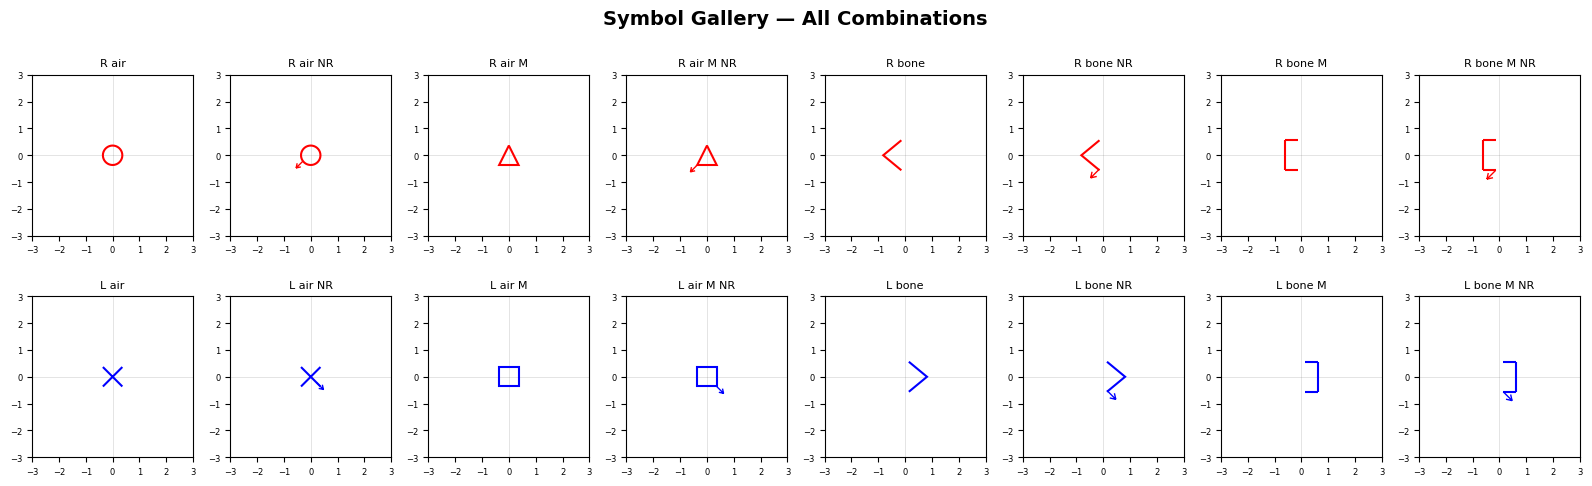

In [2]:
clear_symbol_caches()

combos = []
for ear in ('right', 'left'):
    for kind in ('air', 'bone'):
        for masked in (False, True):
            for nr in (False, True):
                combos.append((ear, kind, masked, nr))

ncols = 8
nrows = (len(combos) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.5))
axes = axes.flatten()

for i, (ear, kind, masked, nr) in enumerate(combos):
    ax = axes[i]
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5, alpha=0.3)
    ax.axvline(0, color='gray', lw=0.5, alpha=0.3)
    
    color = 'red' if ear == 'right' else 'blue'
    s = get_symbol(kind=kind, ear=ear, masked=masked, nr=nr)
    size_pt = DEFAULT_RENDER_CONFIG.style.bone_size_pt if kind == 'bone' else DEFAULT_RENDER_CONFIG.style.air_size_pt
    add_symbol(ax, s, 0, 0, color=color, size_pt=size_pt, cfg=DEFAULT_RENDER_CONFIG)
    
    label = f"{ear[0].upper()} {kind}"
    if masked:
        label += ' M'
    if nr:
        label += ' NR'
    ax.set_title(label, fontsize=8)
    ax.tick_params(labelsize=6)

# Hide unused axes
for j in range(len(combos), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Symbol Gallery — All Combinations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Resize Stability

Symbols are rendered in display space (points → pixels), so they should maintain size regardless of axes limits and figure DPI. This test plots the same symbol at different DPIs.

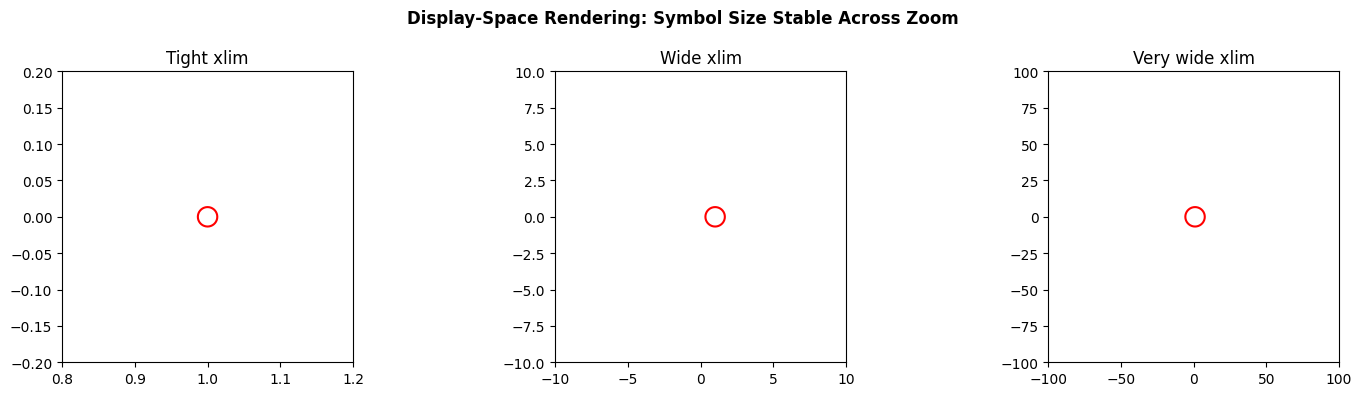

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, dpi_label in zip(axes, ['Tight xlim', 'Wide xlim', 'Very wide xlim']):
    s = get_symbol(kind='air', ear='right', masked=False, nr=False)
    
    if dpi_label == 'Tight xlim':
        ax.set_xlim(0.8, 1.2)
        ax.set_ylim(-0.2, 0.2)
    elif dpi_label == 'Wide xlim':
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)
    else:
        ax.set_xlim(-100, 100)
        ax.set_ylim(-100, 100)
    
    add_symbol(ax, s, 1.0, 0.0, color='red', size_pt=14, cfg=DEFAULT_RENDER_CONFIG)
    ax.set_title(dpi_label)
    ax.set_aspect('equal')

plt.suptitle('Display-Space Rendering: Symbol Size Stable Across Zoom', fontweight='bold')
plt.tight_layout()
plt.show()

## NR Arrow Detail

Zoom in on NR composites to verify arrow attachment points and directionality.
- Right ear NR arrows should point down-left
- Left ear NR arrows should point down-right

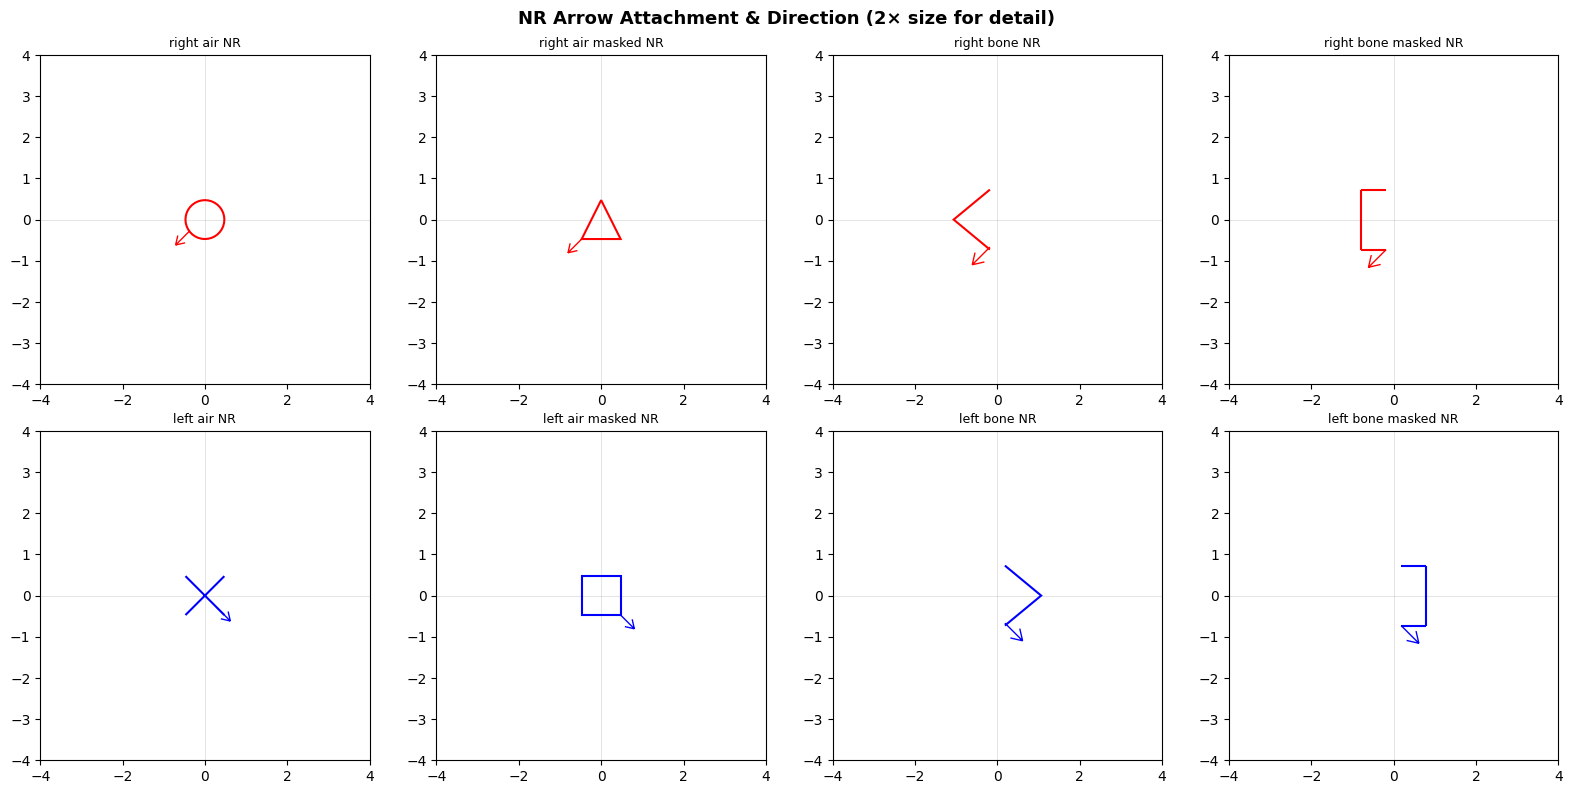

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, ear in enumerate(['right', 'left']):
    color = 'red' if ear == 'right' else 'blue'
    for col, (kind, masked) in enumerate([
        ('air', False), ('air', True), ('bone', False), ('bone', True)
    ]):
        ax = axes[row, col]
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect('equal')
        ax.axhline(0, color='gray', lw=0.5, alpha=0.3)
        ax.axvline(0, color='gray', lw=0.5, alpha=0.3)
        
        s = get_symbol(kind=kind, ear=ear, masked=masked, nr=True)
        size_pt = DEFAULT_RENDER_CONFIG.style.bone_size_pt if kind == 'bone' else DEFAULT_RENDER_CONFIG.style.air_size_pt
        add_symbol(ax, s, 0, 0, color=color, size_pt=size_pt * 2, cfg=DEFAULT_RENDER_CONFIG)
        
        label = f"{ear} {kind}"
        if masked:
            label += ' masked'
        ax.set_title(f'{label} NR', fontsize=9)

plt.suptitle('NR Arrow Attachment & Direction (2× size for detail)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Config Comparison

Default vs TINY render config side by side.

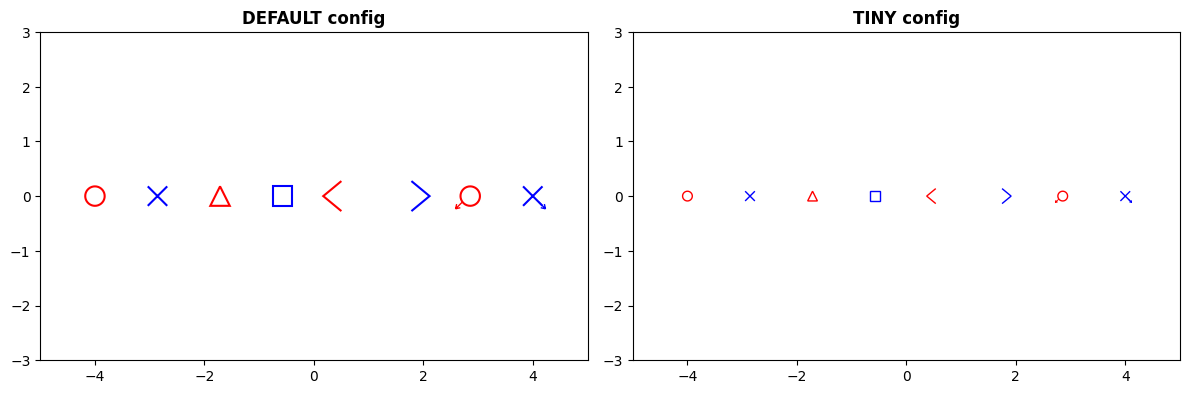

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, cfg, label in [(ax1, DEFAULT_RENDER_CONFIG, 'DEFAULT'), (ax2, TINY_RENDER_CONFIG, 'TINY')]:
    ax.set_xlim(-5, 5)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    
    symbols = [
        ('air', 'right', False, False),
        ('air', 'left', False, False),
        ('air', 'right', True, False),
        ('air', 'left', True, False),
        ('bone', 'right', False, False),
        ('bone', 'left', False, False),
        ('air', 'right', False, True),
        ('air', 'left', False, True),
    ]
    
    xs = np.linspace(-4, 4, len(symbols))
    for x, (kind, ear, masked, nr) in zip(xs, symbols):
        color = 'red' if ear == 'right' else 'blue'
        s = get_symbol(kind=kind, ear=ear, masked=masked, nr=nr, cfg=cfg)
        size_pt = cfg.style.bone_size_pt if kind == 'bone' else cfg.style.air_size_pt
        add_symbol(ax, s, x, 0, color=color, size_pt=size_pt, cfg=cfg)
    
    ax.set_title(f'{label} config', fontweight='bold')

plt.tight_layout()
plt.show()

## Symbols on Audiogram Canvas

Verify symbols render correctly on a real audiogram axes (log x-scale, inverted y).

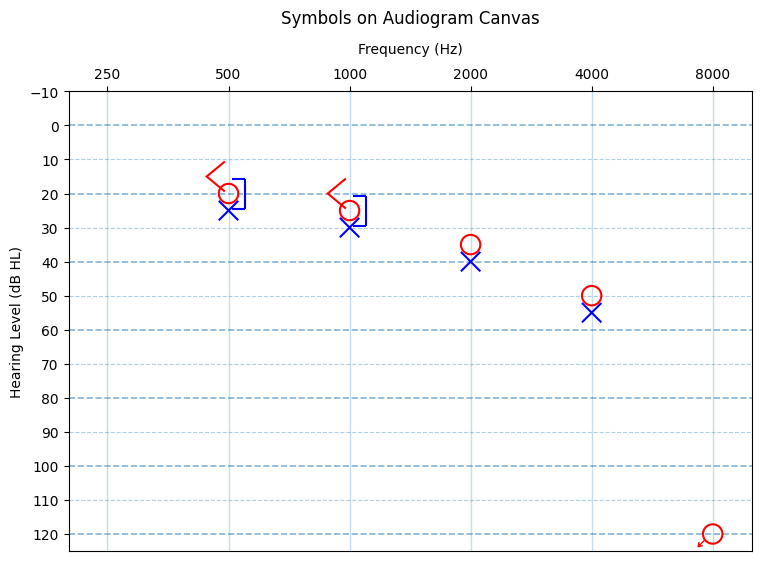

In [6]:
fig, ax = new_audiogram_canvas(preset='ansi', title='Symbols on Audiogram Canvas')

# Right ear air — O at common frequencies
for f, db in [(500, 20), (1000, 25), (2000, 35), (4000, 50)]:
    s = get_symbol(kind='air', ear='right', masked=False, nr=False)
    add_air_symbol(ax, s, f, db, color='red')

# Left ear air — X
for f, db in [(500, 25), (1000, 30), (2000, 40), (4000, 55)]:
    s = get_symbol(kind='air', ear='left', masked=False, nr=False)
    add_air_symbol(ax, s, f, db, color='blue')

# Right bone — chevron
for f, db in [(500, 15), (1000, 20)]:
    s = get_symbol(kind='bone', ear='right', masked=False, nr=False)
    add_bone_symbol(ax, s, f, db, color='red')

# Left bone masked — bracket
for f, db in [(500, 20), (1000, 25)]:
    s = get_symbol(kind='bone', ear='left', masked=True, nr=False)
    add_bone_symbol(ax, s, f, db, color='blue')

# NR at 8000 Hz right
s = get_symbol(kind='air', ear='right', masked=False, nr=True)
add_air_symbol(ax, s, 8000, 120, color='red')

plt.show()

## Text-Based Markers: Soundfield & CI

Soundfield ("S") and CI ("CI") thresholds use text labels instead of path-based symbols.
They are rendered via `_plot_text_series()` with white background boxes for legibility.

- **Soundfield**: green, same on both ears (binaural test)
- **CI aided**: ear-colored (red/blue)

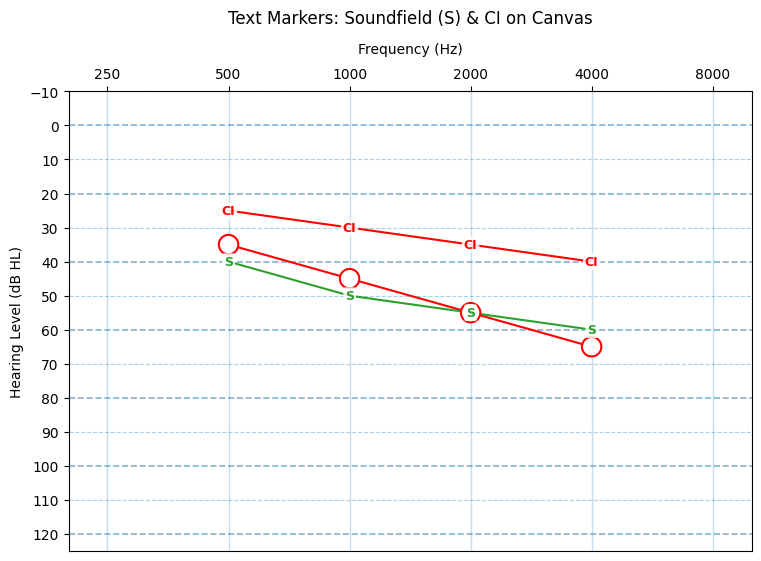

In [7]:
from audiogram.plot_mpl import plot_ear, _plot_text_series

fig, ax = new_audiogram_canvas(preset='ansi', title='Text Markers: Soundfield (S) & CI on Canvas')

# Air conduction for context
plot_ear(
    ax,
    {500: 35, 1000: 45, 2000: 55, 4000: 65},
    ear='right',
    color='red',
)

# Soundfield — green "S"
_plot_text_series(
    ax,
    {500: 40, 1000: 50, 2000: 55, 4000: 60},
    label='S',
    color='#2ca02c',
)

# CI aided — red (right ear)
_plot_text_series(
    ax,
    {500: 25, 1000: 30, 2000: 35, 4000: 40},
    label='CI',
    color='red',
)

plt.show()